# Segmentasi Gigi — Semantic (untuk Deployment iOS)

Melatih model **segmentasi semantik 1-mask** ("tooth vs bukan") yang **jauh lebih mudah
dipakai di Swift** daripada YOLOv8-seg: keluarannya langsung satu mask. Backbone ringan
**LR-ASPP MobileNetV3** (cocok untuk iPhone).

Alur: mask COCO (`data/masks`) → mask biner (image, mask) → latih LR-ASPP → evaluasi (IoU)
→ **ekspor Core ML** (input gambar, output peta probabilitas gigi).

In [1]:
import os, glob, json, sys, subprocess
import numpy as np
def _ensure(p, i):
    try: __import__(i)
    except ImportError: subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', p])
_ensure('pycocotools', 'pycocotools'); _ensure('opencv-python-headless', 'cv2')
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.segmentation import lraspp_mobilenet_v3_large
from pycocotools import mask as coco_mask
from PIL import Image

try:    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError: _HERE = os.getcwd()
PROJECT_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == 'notebooks' else _HERE
DATA_MASKS = os.path.join(PROJECT_ROOT, 'data', 'masks')
DATA_RAW   = os.path.join(PROJECT_ROOT, 'data', 'raw')
SEG_MASKS  = os.path.join(PROJECT_ROOT, 'data', 'seg_masks')     # cache mask biner
MODELS_DIR = os.path.join(PROJECT_ROOT, 'models'); os.makedirs(MODELS_DIR, exist_ok=True)
IMG_SIZE   = 384
RATA, SIMPANG = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
PERANGKAT = ('cuda' if torch.cuda.is_available()
             else ('mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else 'cpu'))
print('Perangkat:', PERANGKAT)

Perangkat: mps


In [2]:
# --- bangun mask biner (union gigi) & pasangkan ke foto raw ---
def nama_asli(fn):
    b = fn.split('.rf.')[0]; s, e = b.rsplit('_', 1); return f'{s}.{e}'
def cari_raw(split, on):
    for c in [on, on[:-4] + '.jpg', on[:-4] + '.JPG']:
        p = os.path.join(DATA_RAW, split, c)
        if os.path.exists(p): return p
    return None

def bangun(split):
    jp = glob.glob(os.path.join(DATA_MASKS, split, '**', '_annotations.coco.json'), recursive=True)[0]
    dj = json.load(open(jp)); tid = [c['id'] for c in dj['categories'] if c['name'] == 'tooth'][0]
    by = {}
    for a in dj['annotations']:
        if a['category_id'] == tid: by.setdefault(a['image_id'], []).append(a['segmentation'])
    dmask = os.path.join(SEG_MASKS, split); os.makedirs(dmask, exist_ok=True)
    pasangan = []
    for im in dj['images']:
        segs = by.get(im['id']); on = nama_asli(im['file_name']); rp = cari_raw(split, on)
        if not segs or rp is None: continue
        H, W = segs[0]['size']; u = np.zeros((H, W), bool)
        for s in segs: u |= coco_mask.decode(s).astype(bool)
        mp = os.path.join(dmask, os.path.splitext(on)[0] + '.png')
        Image.fromarray((u * 255).astype('uint8')).save(mp)
        pasangan.append((rp, mp))
    return pasangan

DATA = {s: bangun(s) for s in ['train', 'val', 'test']}
for s in DATA: print(f'{s:5s}: {len(DATA[s])} pasangan (image, mask)')

train: 374 pasangan (image, mask)
val  : 74 pasangan (image, mask)
test : 106 pasangan (image, mask)


In [3]:
# --- Dataset & DataLoader ---
_norm = transforms.Normalize(RATA, SIMPANG)
class SegDS(Dataset):
    def __init__(self, pasangan, augment=False): self.p = pasangan; self.aug = augment
    def __len__(self): return len(self.p)
    def __getitem__(self, i):
        ip, mp = self.p[i]
        img = Image.open(ip).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        msk = Image.open(mp).convert('L').resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
        if self.aug and np.random.rand() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT); msk = msk.transpose(Image.FLIP_LEFT_RIGHT)
        x = _norm(transforms.functional.to_tensor(img))
        y = torch.from_numpy((np.asarray(msk) > 127).astype('int64'))
        return x, y

dl_tr = DataLoader(SegDS(DATA['train'], True),  batch_size=8, shuffle=True,  num_workers=0)
dl_va = DataLoader(SegDS(DATA['val'],  False),  batch_size=8, shuffle=False, num_workers=0)
dl_te = DataLoader(SegDS(DATA['test'], False),  batch_size=8, shuffle=False, num_workers=0)
print('batch train/val/test:', len(dl_tr), len(dl_va), len(dl_te))

batch train/val/test: 47 10 14


In [4]:
# --- Model LR-ASPP MobileNetV3 (2 kelas: bg, tooth) ---
model = lraspp_mobilenet_v3_large(weights_backbone='DEFAULT', num_classes=2).to(PERANGKAT)

@torch.no_grad()
def iou_split(dl):
    model.eval(); inter = union = 0.0
    for x, y in dl:
        p = model(x.to(PERANGKAT))['out'].argmax(1).cpu()
        inter += ((p == 1) & (y == 1)).sum().item(); union += ((p == 1) | (y == 1)).sum().item()
    return inter / max(union, 1)

def latih(epoch=25, lr=1e-3):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epoch)
    crit = nn.CrossEntropyLoss()
    terbaik, bobot = 0.0, None
    for ep in range(epoch):
        model.train()
        for x, y in dl_tr:
            loss = crit(model(x.to(PERANGKAT))['out'], y.to(PERANGKAT))
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        sched.step(); iv = iou_split(dl_va)
        if iv > terbaik: terbaik = iv; bobot = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f'  epoch {ep+1:2d}/{epoch}  val IoU {iv:.3f}')
    model.load_state_dict(bobot); return terbaik

print('Melatih LR-ASPP...')
val_iou = latih()
torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'teeth_seg_semantic.pt'))
print(f'val IoU terbaik {val_iou:.3f} | test IoU {iou_split(dl_te):.3f} -> models/teeth_seg_semantic.pt')

Melatih LR-ASPP...
  epoch  1/25  val IoU 0.671
  epoch  2/25  val IoU 0.776
  epoch  3/25  val IoU 0.835
  epoch  4/25  val IoU 0.875
  epoch  5/25  val IoU 0.884
  epoch  6/25  val IoU 0.897
  epoch  7/25  val IoU 0.900
  epoch  8/25  val IoU 0.902
  epoch  9/25  val IoU 0.902
  epoch 10/25  val IoU 0.902
  epoch 11/25  val IoU 0.903
  epoch 12/25  val IoU 0.903
  epoch 13/25  val IoU 0.905
  epoch 14/25  val IoU 0.905
  epoch 15/25  val IoU 0.901
  epoch 16/25  val IoU 0.904
  epoch 17/25  val IoU 0.906
  epoch 18/25  val IoU 0.907
  epoch 19/25  val IoU 0.907
  epoch 20/25  val IoU 0.907
  epoch 21/25  val IoU 0.906
  epoch 22/25  val IoU 0.906
  epoch 23/25  val IoU 0.907
  epoch 24/25  val IoU 0.907
  epoch 25/25  val IoU 0.907
val IoU terbaik 0.907 | test IoU 0.905 -> models/teeth_seg_semantic.pt


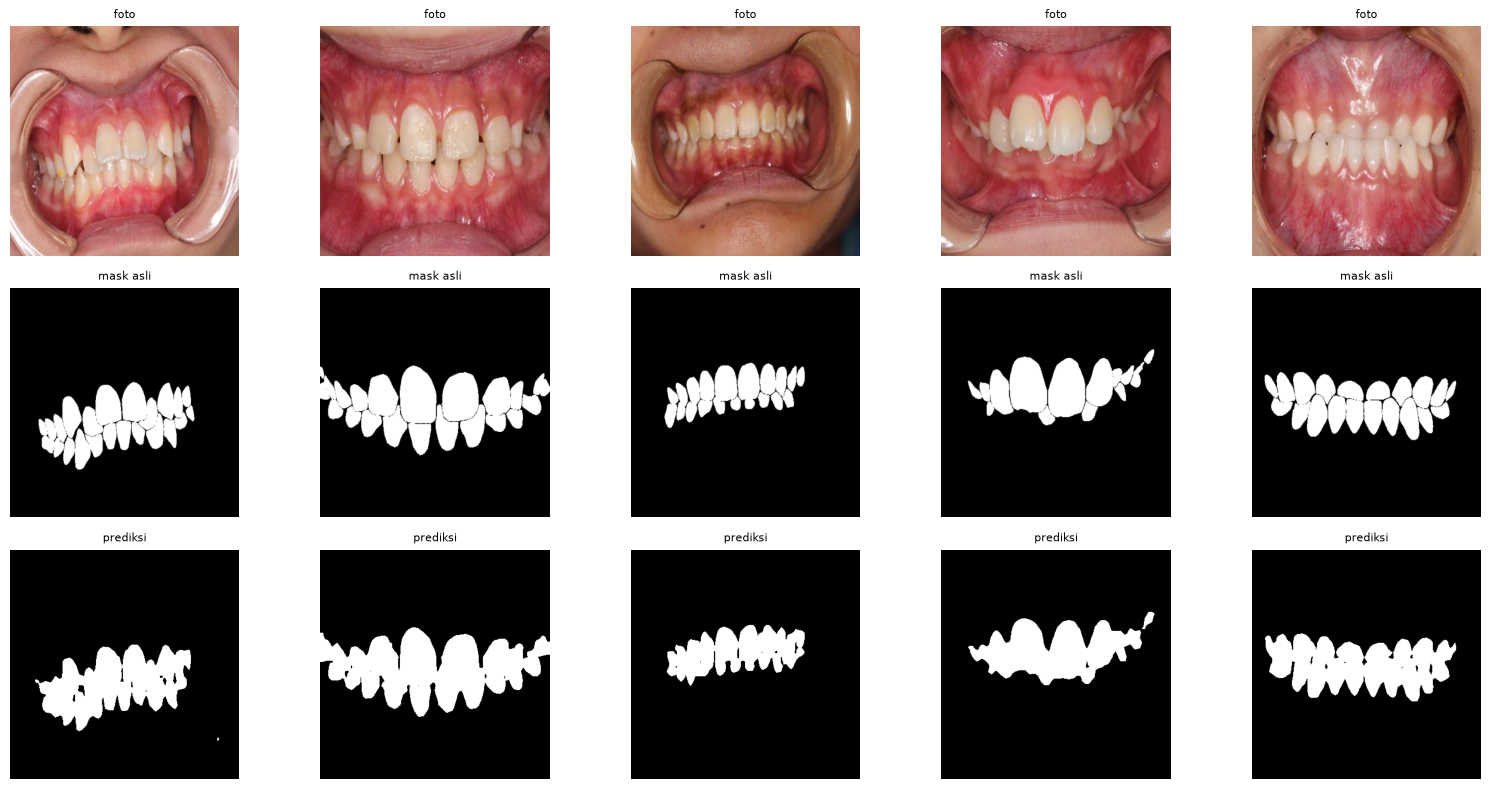

In [5]:
# --- pratinjau prediksi ---
import matplotlib.pyplot as plt
model.eval()
fig, ax = plt.subplots(3, 5, figsize=(16, 8))
for k, (ip, mp) in enumerate(DATA['test'][:5]):
    img = Image.open(ip).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    x = _norm(transforms.functional.to_tensor(img)).unsqueeze(0).to(PERANGKAT)
    with torch.no_grad(): pr = model(x)['out'].argmax(1)[0].cpu().numpy()
    ax[0, k].imshow(img); ax[0, k].set_title('foto', fontsize=8)
    ax[1, k].imshow(Image.open(mp).convert('L').resize((IMG_SIZE, IMG_SIZE)), cmap='gray'); ax[1, k].set_title('mask asli', fontsize=8)
    ax[2, k].imshow(pr, cmap='gray'); ax[2, k].set_title('prediksi', fontsize=8)
    for r in range(3): ax[r, k].axis('off')
plt.tight_layout(); fig.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'semantic_seg_preview.png'), dpi=110, bbox_inches='tight'); plt.show()

In [6]:
# --- ekspor Core ML (input gambar -> peta probabilitas gigi) ---
import copy
try:    import coremltools as ct
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'coremltools']); import coremltools as ct

class SegCoreML(nn.Module):
    """Masukan gambar 1x3xHxW dalam [0,1]; normalisasi ditanam. Keluaran: prob gigi 1x1xHxW (0..1)."""
    def __init__(self, m):
        super().__init__(); self.m = copy.deepcopy(m).cpu().eval()
        self.register_buffer('mean', torch.tensor(RATA).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor(SIMPANG).view(1, 3, 1, 1))
    def forward(self, x):
        out = self.m((x - self.mean) / self.std)['out']
        return torch.softmax(out, 1)[:, 1:2]         # probabilitas kelas 'tooth'

wrap = SegCoreML(model).eval()
ex = torch.rand(1, 3, IMG_SIZE, IMG_SIZE)
with torch.no_grad(): ts = torch.jit.trace(wrap, ex)
mlmodel = ct.convert(ts,
    inputs=[ct.ImageType(name='image', shape=(1, 3, IMG_SIZE, IMG_SIZE), scale=1/255.0, color_layout=ct.colorlayout.RGB)],
    outputs=[ct.TensorType(name='tooth_prob')],
    minimum_deployment_target=ct.target.iOS16)
mlmodel.short_description = 'Segmentasi gigi (semantic) — probabilitas piksel tooth'
jalur = os.path.join(MODELS_DIR, 'teeth_seg_semantic.mlpackage'); mlmodel.save(jalur)
print('Core ML ->', os.path.relpath(jalur, PROJECT_ROOT))

scikit-learn version 1.8.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
XGBoost version 2.0.3 has not been tested with coremltools. You may run into unexpected errors. XGBoost 1.4.2 is the most recent version that has been tested.
Torch version 2.8.0 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 372.62 passes/s]


Core ML -> models/teeth_seg_semantic.mlpackage


## Pakai di app (Swift, ~ ringkas)
- Salin `models/teeth_seg_semantic.mlpackage` ke `IOTN-AC App/MLModels/`.
- `TeethSegmenter` menjalankan model → keluaran `tooth_prob` (peta 0..1 ukuran 384×384) →
  threshold 0.5 → mask biner → resize ke ukuran foto asli → hitung bbox.
- Tidak perlu NMS/prototype seperti YOLOv8-seg — jauh lebih sederhana & andal.